# Document Image Classification
## OCR-based Linear SVM Classifier

**Project:** Document classification using OCR + Linear SVM  
**Framework:** scikit-learn LinearSVC  
**Platform:** Windows / Local

---

###  Notebook Map
| Section | Description |
|---------|-------------|
| 1 | Setup & Imports |
| 2 | Configuration — Data |
| 3 | Dataset Loading |
| 4 | OCR Text Extraction |
| 5 | OCR-SVM Pipeline (Linear SVM) |
| 6 | Evaluation — 5 Metrics per Class + Visual Diagrams |


---
##  Section 1 — Setup & Imports

**Before running:**
1. Install Tesseract OCR (Windows): https://github.com/UB-Mannheim/tesseract/wiki
2. Set `tesseract_cmd` path in Section 2 if needed
3. Run `pip install opencv-python pytesseract scikit-learn tqdm matplotlib seaborn pillow` in your terminal


In [1]:
import os
import re
import json
import random
import warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

import numpy as np
import pandas as pd

from tqdm import tqdm
from PIL import Image
import cv2
import pytesseract

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
!{sys.executable} -m pip install opencv-python pytesseract scikit-learn tqdm matplotlib seaborn pillow --quiet


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, sys, re, json, pickle, random, shutil, warnings
from pathlib import Path
from collections import defaultdict

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

# ── OpenCV ────────────────────────────────────────────────────────────────────
import cv2

# ── OCR ───────────────────────────────────────────────────────────────────────
import pytesseract

# ── Sklearn (TF-IDF + Linear SVM) ────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

warnings.filterwarnings("ignore")
print("All imports OK")


All imports OK


---
##  Section 2 — Configuration

> **Only edit this cell.** Point `DATA_DIR` to your dataset root.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  ★  EDIT THESE  ★
# ─────────────────────────────────────────────────────────────────────────────

# Root folder containing train/, val/, test/ subfolders
DATA_DIR = r"C:\Users\DPQUAI250127\Downloads\data"

# Windows Tesseract path — uncomment and adjust if tesseract is not on PATH
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

RANDOM_SEED   = 42

# ── OCR cache (delete these files to force re-extraction) ────────────────────
OCR_CACHE_DIR = "ocr_cache"

# ── Output directories ────────────────────────────────────────────────────────
Path("results").mkdir(exist_ok=True)
Path(OCR_CACHE_DIR).mkdir(exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Image extensions ─────────────────────────────────────────────────────────
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
TRAIN_DIR  = Path(DATA_DIR) / "train"
VAL_DIR    = Path(DATA_DIR) / "val"
TEST_DIR   = Path(DATA_DIR) / "test"

# ── Validate DATA_DIR ─────────────────────────────────────────────────────────
all_ok = True
for split_dir, name in [(TRAIN_DIR, "train"), (VAL_DIR, "val"), (TEST_DIR, "test")]:
    if not split_dir.exists():
        print(f"⚠  {name}/ not found at: {split_dir}")
        all_ok = False
    else:
        classes_found = [d.name for d in sorted(split_dir.iterdir()) if d.is_dir()]
        n_img = sum(1 for p in split_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
        print(f"✓ {name:5s}: {len(classes_found)} classes, {n_img} images  →  {classes_found}")

if all_ok:
    CLASS_NAMES = [d.name for d in sorted(TRAIN_DIR.iterdir()) if d.is_dir()]
    NUM_CLASSES = len(CLASS_NAMES)
    print(f'\nNUM_CLASSES = {NUM_CLASSES}  |  Classes: {CLASS_NAMES}')


✓ train: 16 classes, 11046 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']
✓ val  : 16 classes, 1550 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']
✓ test : 16 classes, 1534 images  →  ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']

NUM_CLASSES = 16  |  Classes: ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']


---
##  Section 3 — Dataset Loading

Scan the dataset directory tree and build a simple index DataFrame for each split.


Train samples : 11046
Val   samples : 1550
Test  samples : 1534
Classes       : ['Advertisement', 'Budget', 'Email', 'FileFolder', 'Form', 'Handwritten', 'Invoice', 'Letter', 'Memo', 'News', 'Presentation', 'Questionnaire', 'Resume', 'ScientificPub', 'ScientificReport', 'Specification']


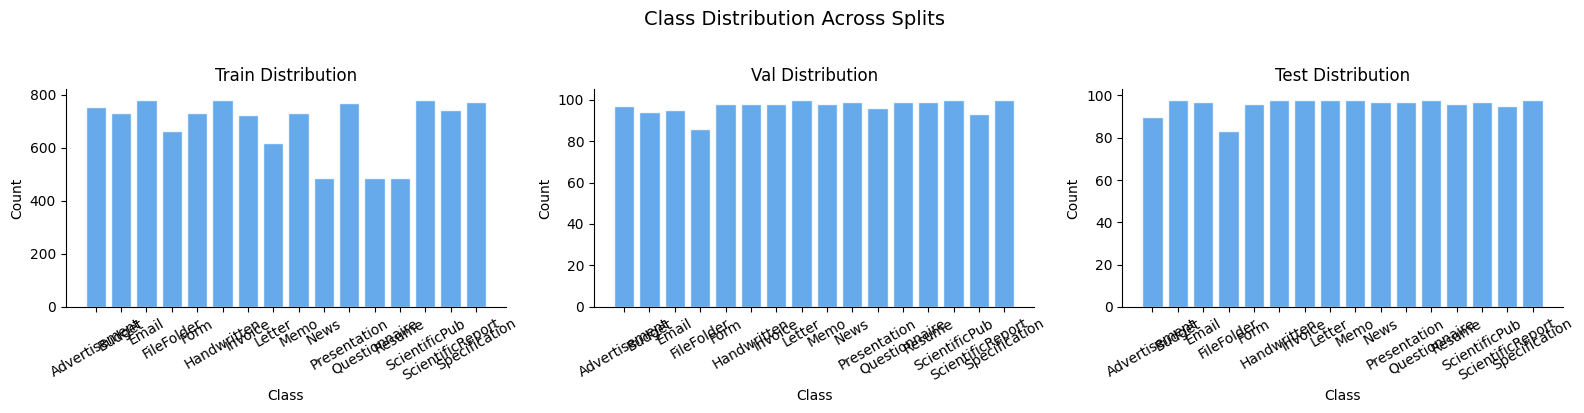

In [4]:
# ── Build image index DataFrames ─────────────────────────────────────────────
def build_index(split_dir: Path) -> pd.DataFrame:
    records = []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir(): continue
        for p in cls_dir.rglob("*"):
            if p.suffix.lower() in IMAGE_EXTS:
                records.append({"path": str(p), "label": cls_dir.name})
    return pd.DataFrame(records)

df_train_idx = build_index(TRAIN_DIR)
df_val_idx   = build_index(VAL_DIR)
df_test_idx  = build_index(TEST_DIR)

print(f"Train samples : {len(df_train_idx)}")
print(f"Val   samples : {len(df_val_idx)}")
print(f"Test  samples : {len(df_test_idx)}")
print(f"Classes       : {sorted(df_train_idx.label.unique())}")

# ── Class distribution bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, title in zip(axes,
                          [df_train_idx, df_val_idx, df_test_idx],
                          ["Train", "Val", "Test"]):
    counts = df["label"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#4C9BE8", alpha=0.85, edgecolor="white")
    ax.set_title(f"{title} Distribution", fontsize=12)
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Class Distribution Across Splits", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


---
##  Section 4 — OCR Text Extraction

We use **Tesseract OCR** to convert document images into raw text.  
The extracted text is then cleaned and fed into a TF-IDF vectorizer.

> Results are cached to disk — delete `ocr_cache/` to force re-extraction.


In [5]:
import os
import pytesseract

tess_path = r"C:\Users\DPQUAI250127\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

# check if file exists
if os.path.exists(tess_path):
    print(f"Tesseract found at: {tess_path}")
    pytesseract.pytesseract.tesseract_cmd = tess_path
else:
    print("Tesseract NOT found at this path")

Tesseract found at: C:\Users\DPQUAI250127\AppData\Local\Programs\Tesseract-OCR\tesseract.exe


In [6]:
try:
    print("Version:", pytesseract.get_tesseract_version())
except Exception as e:
    print("Error:", e)

Version: 5.5.0.20241111


In [7]:
from tqdm import tqdm

print("tqdm =", tqdm)
print("module =", tqdm.__module__)

tqdm = <class 'tqdm.std.tqdm'>
module = tqdm.std


In [8]:
# ── Preprocessing for OCR ─────────────────────────────────────────────────────
# PSM 3 is fully automatic page segmentation (better for complex documents)
TESS_CONFIG = '--oem 3 --psm 3 -l eng'

def preprocess_for_ocr(image_path: str) -> np.ndarray:
    """Upscale and Grayscale only. Less aggressive than before."""
    img = cv2.imread(str(image_path))
    if img is None:
        pil = Image.open(str(image_path)).convert('RGB')
        img = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    h, w = img.shape[:2]
    # Simple resizing if too small
    if max(h, w) < 1000:
        scale = 1000 / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

def extract_text(image_path: str) -> str:
    """Run Tesseract with fallback logic."""
    try:
        # 1. Try with processed image
        proc_img = preprocess_for_ocr(image_path)
        text = pytesseract.image_to_string(proc_img, config=TESS_CONFIG)

        # 2. Fallback: If text is extremely short, try raw image
        if len(text.strip()) < 5:
            raw_img = cv2.imread(str(image_path))
            text = pytesseract.image_to_string(raw_img, config=TESS_CONFIG)

        return ' '.join(text.split()).strip()
    except Exception as e:
        return ''

def clean_text(text: str) -> str:
    """Lowercase, remove single-char artifacts, keep alphanumeric."""
    text = str(text).lower()
    text = re.sub(r'\b\w{1}\b', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_split(
    split_dir: Path, cache_file: str, desc: str = 'OCR'
) -> pd.DataFrame:
    """Walk split dir, run OCR on each image, cache results."""
    cache_path = Path(OCR_CACHE_DIR) / cache_file

    # IMPORTANT: Delete the old cache file if it exists, otherwise
    # it will just load the old empty results!
    if cache_path.exists():
        print(f'  Removing old cache: {cache_path}')
        os.remove(cache_path)

    records = []
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for class_dir in class_dirs:
        paths = [p for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
        for p in tqdm(paths, desc=f'{desc}/{class_dir.name}', leave=False):
            raw   = extract_text(str(p))
            clean = clean_text(raw)
            records.append({
                'path': str(p), 'label': class_dir.name,
                'raw_text': raw, 'clean_text': clean,
                'word_count': len(clean.split())
            })

    df = pd.DataFrame(records)
    df.to_json(cache_path, orient='records', indent=2)
    print(f'  Saved {len(df)} records → {cache_path}')
    return df

# ── Extract all splits ────────────────────────────────────────────────────────
print('Extracting OCR text… (this may take a while)\n')
df_train_ocr = extract_split(TRAIN_DIR, 'ocr_train.json', 'Train')
df_val_ocr   = extract_split(VAL_DIR,   'ocr_val.json',   'Val')
df_test_ocr  = extract_split(TEST_DIR,  'ocr_test.json',  'Test')

Extracting OCR text… (this may take a while)



  Saved 11046 records → ocr_cache\ocr_train.json
  Removing old cache: ocr_cache\ocr_val.json


  Saved 1550 records → ocr_cache\ocr_val.json
  Removing old cache: ocr_cache\ocr_test.json


  Saved 1534 records → ocr_cache\ocr_test.json


---
##  Section 5 — OCR-SVM Pipeline (Linear SVM)

Pipeline:
1. **TF-IDF** vectorize the OCR text (sklearn)
2. **LinearSVC** with `CalibratedClassifierCV` wrapper for probability estimates
3. Evaluate with 5 per-class metrics — no epochs, no GPU needed

> **Why Linear SVM over CNN?**  
> LinearSVC is highly efficient on high-dimensional sparse TF-IDF vectors, trains in seconds, and typically outperforms shallow neural networks on text classification when features are already well-engineered.


In [9]:
# ── TF-IDF vectorization (fine-tuned) ───────────────────────────────────────
MIN_WORDS = 3

# Filter out near-empty OCR results
df_tr = df_train_ocr[df_train_ocr['word_count'] >= MIN_WORDS].copy()
df_v  = df_val_ocr[df_val_ocr['word_count']   >= MIN_WORDS].copy()
df_te = df_test_ocr[df_test_ocr['word_count'] >= MIN_WORDS].copy()

if df_tr.empty:
    raise RuntimeError(
        'No training samples with OCR text found.\n'
        'Fix Tesseract, delete ocr_cache/, and re-run Section 5.'
    )

# Label encoding
le = LabelEncoder()
le.fit(df_tr['label'])
ocr_classes = le.classes_

# Keep only classes seen in training
df_v  = df_v[df_v['label'].isin(ocr_classes)].copy()
df_te = df_te[df_te['label'].isin(ocr_classes)].copy()

# ── Fine-tuned TF-IDF ────────────────────────────────────────────────────────
# Key improvements over the baseline:
#   • max_features=50_000  — larger vocab captures more document-specific terms
#   • ngram_range=(1, 3)   — trigrams catch domain phrases (e.g. 'net 30 days')
#   • min_df=2             — prune hapax legomena (OCR noise)
#   • max_df=0.90          — drop near-universal stop words missed by tokenizer
#   • sublinear_tf=True    — log(1+tf) dampens high-frequency terms
#   • analyzer='word'      — word-level tokens (best for clean OCR output)
#   • norm='l2'            — unit-norm rows (SVM is margin-based; L2 helps)
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    ngram_range=(1, 3),          # unigrams, bigrams, trigrams
    max_features=50_000,         # wider vocabulary than baseline (was 30_000)
    min_df=2,                    # ignore very rare tokens (OCR artefacts)
    max_df=0.90,                 # ignore tokens that appear in >90% of docs
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'(?u)\b\w\w+\b',  # require >= 2 chars (drops single chars)
    norm='l2',                   # L2 normalisation — ideal for SVM margins
)

# Fit on training set, transform all splits
X_tr_tfidf = tfidf.fit_transform(df_tr['clean_text'])
X_v_tfidf  = tfidf.transform(df_v['clean_text'])
X_te_tfidf = tfidf.transform(df_te['clean_text'])

y_tr = le.transform(df_tr['label'])
y_v  = le.transform(df_v['label'])
y_te = le.transform(df_te['label'])

TFIDF_DIM = X_tr_tfidf.shape[1]
print(f'TF-IDF feature dim : {TFIDF_DIM}')
print(f'Train samples      : {X_tr_tfidf.shape[0]}')
print(f'Val   samples      : {X_v_tfidf.shape[0]}')
print(f'Test  samples      : {X_te_tfidf.shape[0]}')
print(f'Matrix density     : {X_tr_tfidf.nnz / (X_tr_tfidf.shape[0] * X_tr_tfidf.shape[1]):.4%}')


TF-IDF feature dim : 50000
Train samples      : 10137
Val   samples      : 1440
Test  samples      : 1406
Matrix density     : 0.2100%


In [10]:
# ── Linear SVM model ─────────────────────────────────────────────────────────
# LinearSVC: efficient primal-solver for large sparse TF-IDF matrices
#   C=0.5    — moderate regularisation (helps generalise on noisy OCR text)
#   max_iter=2000 — ensure convergence on larger datasets
#   class_weight='balanced' — handles class imbalance automatically
#
# CalibratedClassifierCV wraps LinearSVC with Platt scaling (isotonic=False)
# so we can produce probability estimates (used for confidence reporting).

base_svm = LinearSVC(
    C=0.5,
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_SEED,
)

svm_model = CalibratedClassifierCV(base_svm, cv=3, method='sigmoid')

print('Linear SVM (LinearSVC + CalibratedClassifierCV) ready')
print(f'  C              : {base_svm.C}')
print(f'  max_iter       : {base_svm.max_iter}')
print(f'  class_weight   : {base_svm.class_weight}')
print(f'  Calibration    : sigmoid (Platt scaling, cv=3)')
print(f'  Input features : {TFIDF_DIM}')


Linear SVM (LinearSVC + CalibratedClassifierCV) ready
  C              : 0.5
  max_iter       : 2000
  class_weight   : balanced
  Calibration    : sigmoid (Platt scaling, cv=3)
  Input features : 50000


Fitting Linear SVM on TF-IDF features…
Training done in 0.8s

Val Accuracy  : 0.7132
Test Accuracy : 0.7361


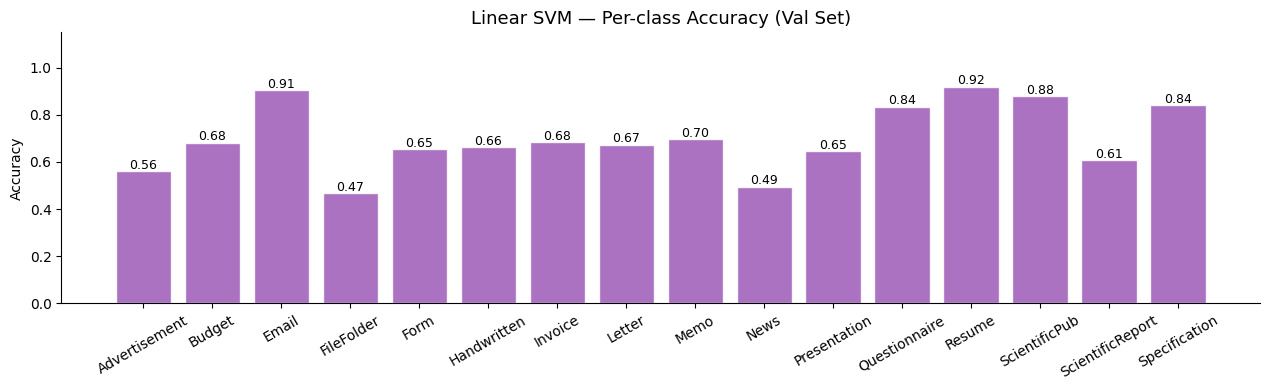


✅ Best Val Accuracy (SVM): 0.7132
   Test Accuracy  (SVM): 0.7361


In [11]:
# ── Train Linear SVM ─────────────────────────────────────────────────────────
import time
from sklearn.metrics import accuracy_score

print('Fitting Linear SVM on TF-IDF features…')
t0 = time.time()
svm_model.fit(X_tr_tfidf, y_tr)
elapsed = time.time() - t0
print(f'Training done in {elapsed:.1f}s')

# ── Validation evaluation ─────────────────────────────────────────────────────
svm_val_preds = svm_model.predict(X_v_tfidf)
svm_val_acc   = accuracy_score(y_v, svm_val_preds)
print(f'\nVal Accuracy  : {svm_val_acc:.4f}')

# ── Test evaluation ───────────────────────────────────────────────────────────
svm_preds    = svm_model.predict(X_te_tfidf)
svm_test_acc = accuracy_score(y_te, svm_preds)
svm_true     = y_te
print(f'Test Accuracy : {svm_test_acc:.4f}')

# Alias for compatibility with Section 7 evaluation code
best_svm_val_acc = svm_val_acc
mlp_val_acc      = svm_val_acc   # keep old name so Section 7 plots work
mlp_test_acc     = svm_test_acc
mlp_preds        = list(svm_preds)
mlp_true         = list(svm_true)
best_mlp_val_acc = best_svm_val_acc

# ── Per-class accuracy bar chart ─────────────────────────────────────────────
from sklearn.metrics import confusion_matrix as _cm
cm_val     = _cm(y_v, svm_val_preds)
per_class  = cm_val.diagonal() / cm_val.sum(axis=1)
class_lbls = [ocr_classes[i] for i in range(len(ocr_classes))]

fig, ax = plt.subplots(figsize=(max(8, len(class_lbls) * 0.8), 4))
bars = ax.bar(class_lbls, per_class, color='#9B59B6', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Linear SVM — Per-class Accuracy (Val Set)', fontsize=13)
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/svm_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Best Val Accuracy (SVM): {best_svm_val_acc:.4f}')
print(f'   Test Accuracy  (SVM): {svm_test_acc:.4f}')


---
##  Section 6 — Evaluation: 5 Metrics per Class + Visual Diagrams

We compute **5 metrics per class** on the test set:

| Metric | Description |
|--------|-------------|
| **Precision** | TP / (TP + FP) — how many predicted positives are correct |
| **Recall** | TP / (TP + FN) — how many actual positives are found |
| **F1-Score** | Harmonic mean of Precision & Recall |
| **Support** | Number of true instances per class |
| **Per-Class Accuracy** | Diagonal of normalised confusion matrix |

Additionally, we report **overall** (macro-averaged) totals.


In [12]:
# ── 5 Metrics per class ───────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

# Compute per-class precision, recall, f1, support
precision, recall, f1, support = precision_recall_fscore_support(
    svm_true, svm_preds, labels=list(range(len(ocr_classes))), zero_division=0
)

# Per-class accuracy from normalised confusion matrix diagonal
cm = confusion_matrix(svm_true, svm_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# ── Build per-class DataFrame ─────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Class"          : list(ocr_classes),
    "Precision"      : precision,
    "Recall"         : recall,
    "F1-Score"       : f1,
    "Support"        : support.astype(int),
    "Per-Class Acc"  : per_class_acc,
})

# ── Overall (macro) row ───────────────────────────────────────────────────────
overall = pd.DataFrame([{
    "Class"         : "OVERALL (macro)",
    "Precision"     : precision.mean(),
    "Recall"        : recall.mean(),
    "F1-Score"      : f1.mean(),
    "Support"       : support.sum(),
    "Per-Class Acc" : per_class_acc.mean(),
}])

metrics_full = pd.concat([metrics_df, overall], ignore_index=True)

# Print nicely formatted table
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 10)
print("=" * 75)
print("  OCR-SVM — 5 Metrics per Class + Overall (Test Set)")
print("=" * 75)
print(metrics_full.to_string(index=False))
print("=" * 75)

metrics_full.to_csv("results/svm_5metrics_per_class.csv", index=False)
print("\nSaved → results/svm_5metrics_per_class.csv")


  OCR-SVM — 5 Metrics per Class + Overall (Test Set)
           Class  Precision  Recall  F1-Score  Support  Per-Class Acc
   Advertisement     0.6885  0.6000    0.6412       70         0.6000
          Budget     0.6364  0.7447    0.6863       94         0.7447
           Email     0.9326  0.8830    0.9071       94         0.8830
      FileFolder     0.3333  0.6389    0.4381       36         0.6389
            Form     0.7875  0.6923    0.7368       91         0.6923
     Handwritten     0.5385  0.6806    0.6012       72         0.6806
         Invoice     0.8000  0.7158    0.7556       95         0.7158
          Letter     0.7975  0.6495    0.7159       97         0.6495
            Memo     0.7103  0.7755    0.7415       98         0.7755
            News     0.7467  0.6222    0.6788       90         0.6222
    Presentation     0.6277  0.6211    0.6243       95         0.6211
   Questionnaire     0.9195  0.8511    0.8840       94         0.8511
          Resume     0.9574  0.9375  

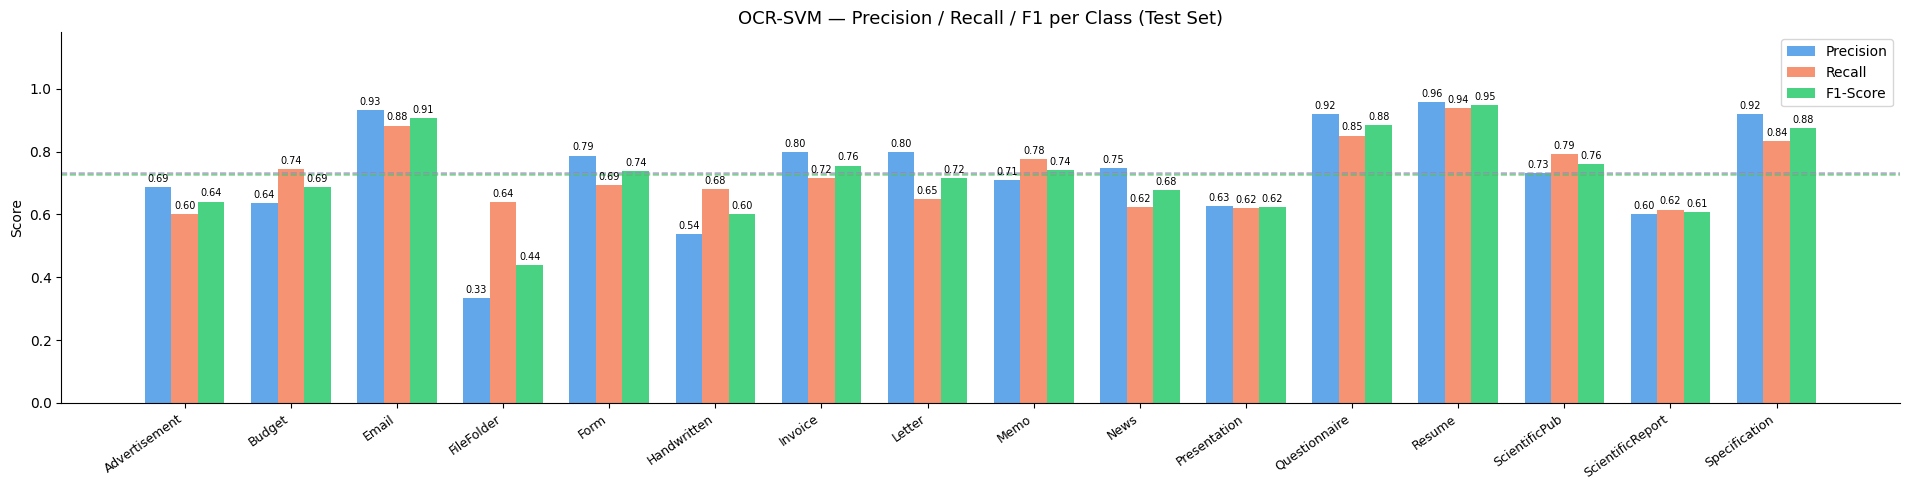

Saved → results/svm_precision_recall_f1.png


In [13]:
# ── Visual 1: Grouped bar chart — Precision / Recall / F1 per class ──────────
classes_plot = list(ocr_classes)
x = np.arange(len(classes_plot))
w = 0.25

fig, ax = plt.subplots(figsize=(max(10, len(classes_plot) * 1.2), 5))
b1 = ax.bar(x - w,   metrics_df["Precision"],    w, label="Precision",   color="#4C9BE8", alpha=0.88)
b2 = ax.bar(x,       metrics_df["Recall"],       w, label="Recall",      color="#F4845F", alpha=0.88)
b3 = ax.bar(x + w,   metrics_df["F1-Score"],     w, label="F1-Score",    color="#2ECC71", alpha=0.88)

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

# Overall macro lines
ax.axhline(precision.mean(), color="#4C9BE8", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(recall.mean(),    color="#F4845F", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(f1.mean(),        color="#2ECC71", linestyle="--", linewidth=1.2, alpha=0.6)

ax.set_xticks(x); ax.set_xticklabels(classes_plot, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score")
ax.set_title("OCR-SVM — Precision / Recall / F1 per Class (Test Set)", fontsize=13)
ax.legend(loc="upper right")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_precision_recall_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_precision_recall_f1.png")


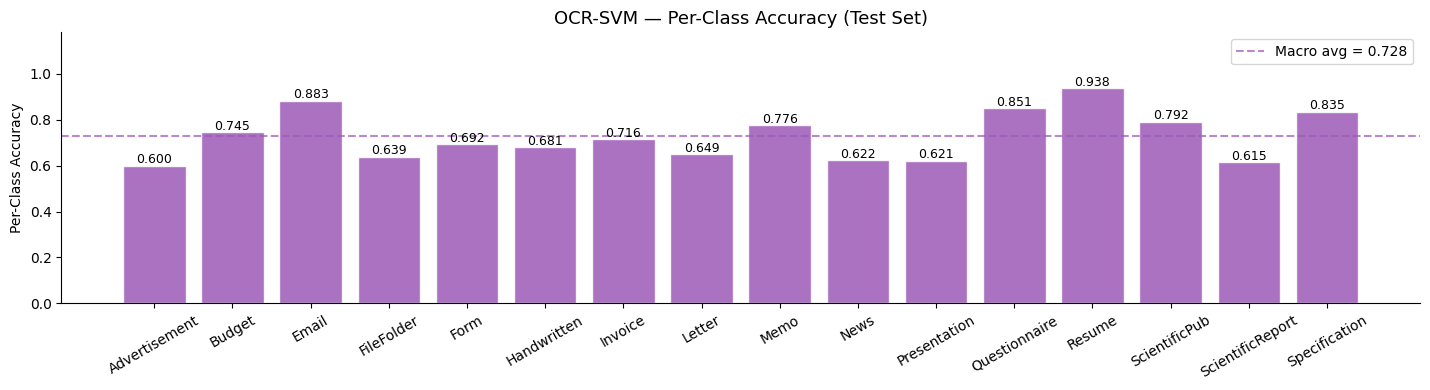

Saved → results/svm_per_class_accuracy.png


In [14]:
# ── Visual 2: Per-class accuracy bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(classes_plot) * 0.9), 4))
bars = ax.bar(classes_plot, metrics_df["Per-Class Acc"],
              color="#9B59B6", alpha=0.85, edgecolor="white")
ax.axhline(per_class_acc.mean(), color="#9B59B6", linestyle="--",
           linewidth=1.5, alpha=0.7, label=f"Macro avg = {per_class_acc.mean():.3f}")
for bar, val in zip(bars, metrics_df["Per-Class Acc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Per-Class Accuracy")
ax.set_title("OCR-SVM — Per-Class Accuracy (Test Set)", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_per_class_accuracy.png")


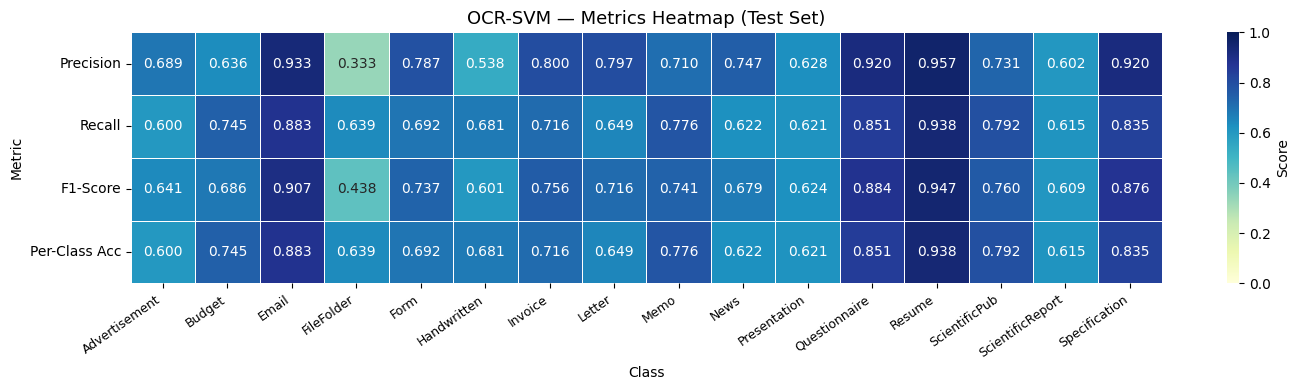

Saved → results/svm_metrics_heatmap.png


In [15]:
# ── Visual 3: Metrics heatmap (all 5 metrics × all classes) ─────────────────
heatmap_data = metrics_df.set_index("Class")[["Precision","Recall","F1-Score","Per-Class Acc"]].astype(float)

fig, ax = plt.subplots(figsize=(max(8, len(classes_plot) * 0.9), 4))
sns.heatmap(
    heatmap_data.T, annot=True, fmt=".3f", cmap="YlGnBu",
    vmin=0, vmax=1, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Score"},
    ax=ax
)
ax.set_title("OCR-SVM — Metrics Heatmap (Test Set)", fontsize=13)
ax.set_xlabel("Class"); ax.set_ylabel("Metric")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("results/svm_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_metrics_heatmap.png")


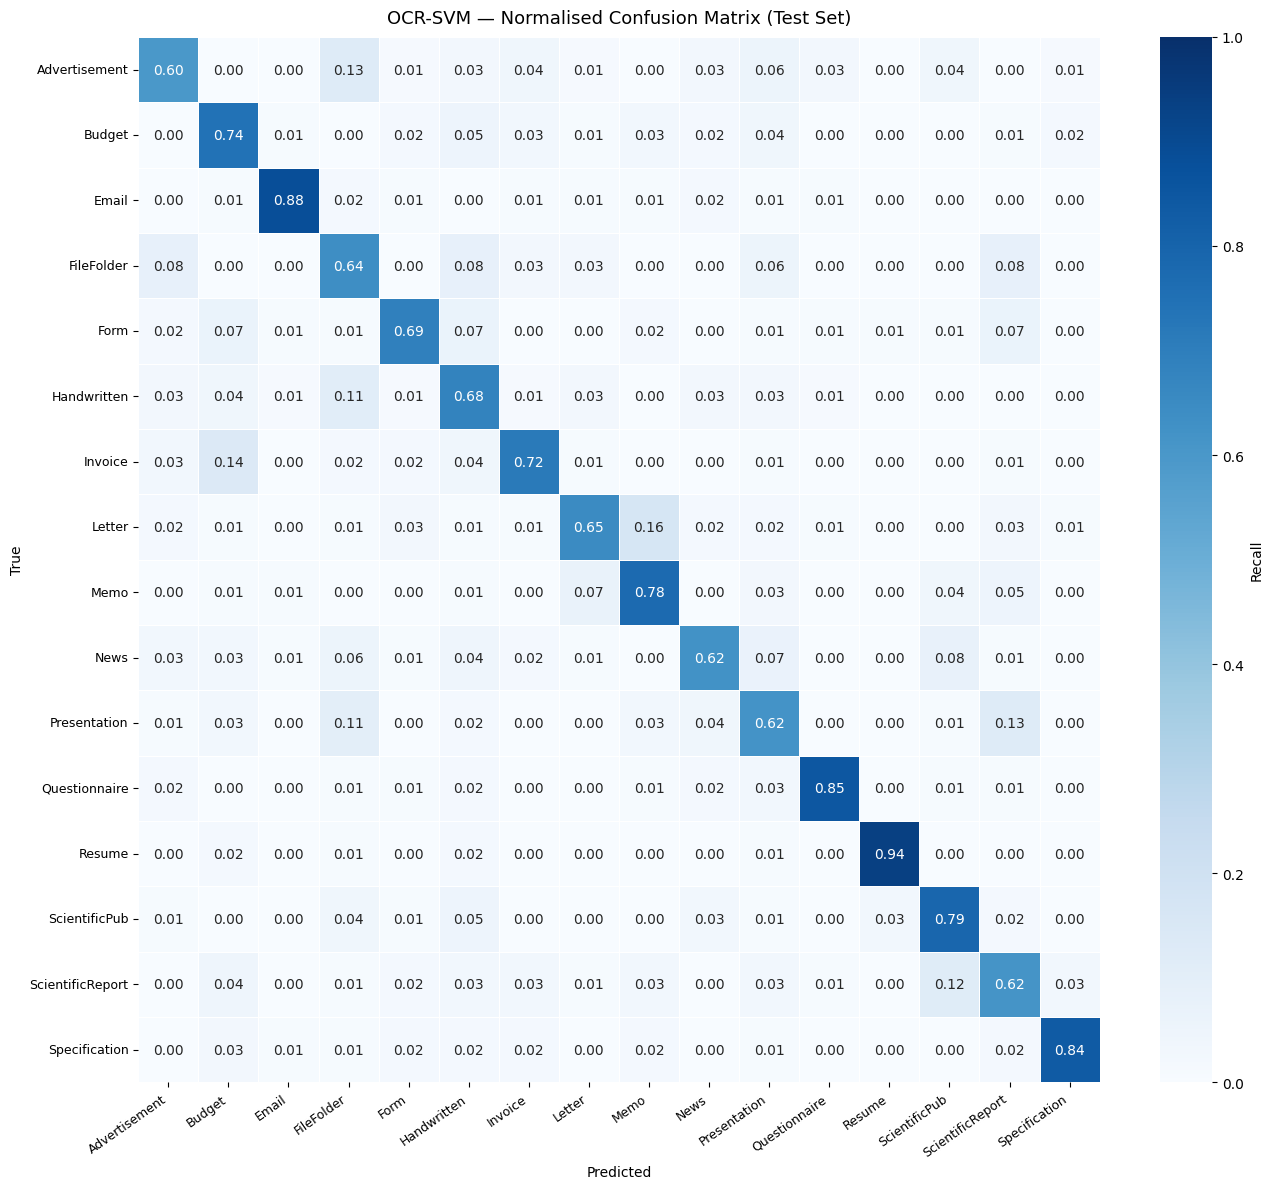

Saved → results/svm_confusion_matrix.png


In [16]:
# ── Visual 4: Normalised Confusion Matrix ────────────────────────────────────
norm_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n = len(ocr_classes)
fig, ax = plt.subplots(figsize=(max(8, n*0.85), max(6, n*0.75)))
sns.heatmap(norm_cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=list(ocr_classes), yticklabels=list(ocr_classes),
            linewidths=0.4, vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Recall"})
ax.set_title("OCR-SVM — Normalised Confusion Matrix (Test Set)", fontsize=13, pad=10)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("results/svm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_confusion_matrix.png")


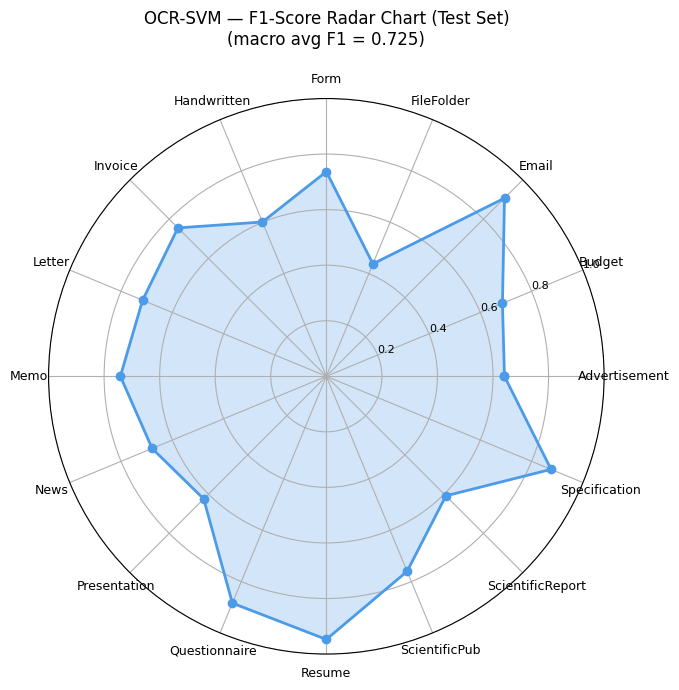

Saved → results/svm_f1_radar.png


In [17]:
# ── Visual 5: Radar chart — F1-score per class ───────────────────────────────
import matplotlib.patches as mpatches
import math

labels_r = list(ocr_classes)
values   = list(metrics_df["F1-Score"])
N        = len(labels_r)
angles   = [2 * math.pi * i / N for i in range(N)] + [2 * math.pi * 0 / N]  # close
values_r = values + [values[0]]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.plot(angles, values_r, "o-", linewidth=2, color="#4C9BE8")
ax.fill(angles, values_r, alpha=0.25, color="#4C9BE8")
ax.set_thetagrids(np.degrees(angles[:-1]), labels_r, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8)
ax.set_title("OCR-SVM — F1-Score Radar Chart (Test Set)\n"
             f"(macro avg F1 = {f1.mean():.3f})", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("results/svm_f1_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_f1_radar.png")


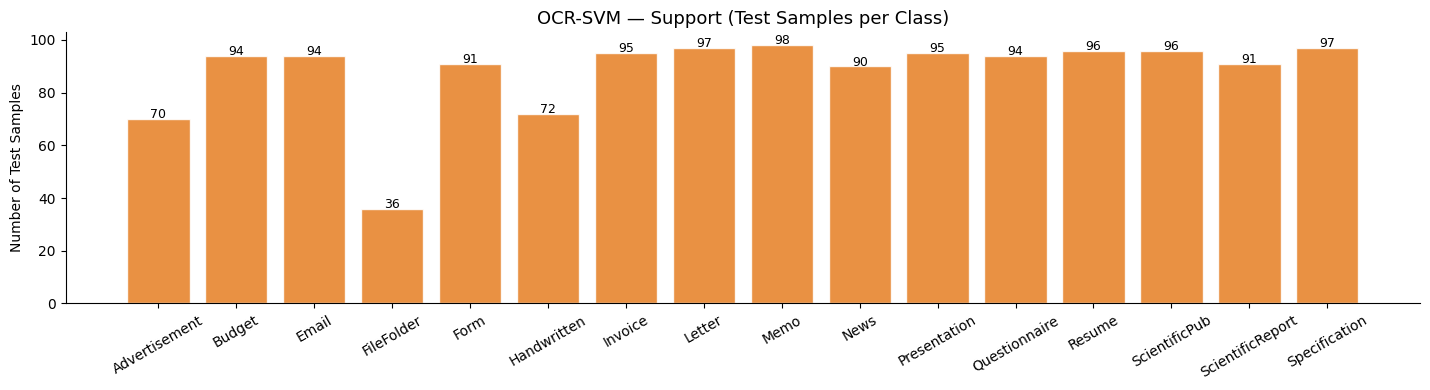

Saved → results/svm_support.png


In [18]:
# ── Visual 6: Support (sample count) per class ────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(classes_plot) * 0.9), 4))
bars = ax.bar(classes_plot, metrics_df["Support"],
              color="#E67E22", alpha=0.85, edgecolor="white")
for bar, val in zip(bars, metrics_df["Support"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(val)), ha="center", fontsize=9)
ax.set_ylabel("Number of Test Samples")
ax.set_title("OCR-SVM — Support (Test Samples per Class)", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("results/svm_support.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/svm_support.png")


In [19]:
# ── Final summary printout ────────────────────────────────────────────────────
print("=" * 75)
print("  OCR-SVM  —  FINAL EVALUATION SUMMARY (Test Set)")
print("=" * 75)
print(f"  Overall Accuracy      : {accuracy_score(svm_true, svm_preds):.4f}")
print(f"  Macro Precision       : {precision.mean():.4f}")
print(f"  Macro Recall          : {recall.mean():.4f}")
print(f"  Macro F1-Score        : {f1.mean():.4f}")
print(f"  Macro Per-Class Acc   : {per_class_acc.mean():.4f}")
print(f"  Total Test Samples    : {int(support.sum())}")
print("=" * 75)
print("\nPer-class breakdown:")
for i, cls in enumerate(ocr_classes):
    print(f"  {cls:<25s}  "
          f"Prec={precision[i]:.3f}  "
          f"Rec={recall[i]:.3f}  "
          f"F1={f1[i]:.3f}  "
          f"Acc={per_class_acc[i]:.3f}  "
          f"N={int(support[i])}")
print("=" * 75)
print("\nAll results saved in results/")


  OCR-SVM  —  FINAL EVALUATION SUMMARY (Test Set)
  Overall Accuracy      : 0.7361
  Macro Precision       : 0.7331
  Macro Recall          : 0.7284
  Macro F1-Score        : 0.7252
  Macro Per-Class Acc   : 0.7284
  Total Test Samples    : 1406

Per-class breakdown:
  Advertisement              Prec=0.689  Rec=0.600  F1=0.641  Acc=0.600  N=70
  Budget                     Prec=0.636  Rec=0.745  F1=0.686  Acc=0.745  N=94
  Email                      Prec=0.933  Rec=0.883  F1=0.907  Acc=0.883  N=94
  FileFolder                 Prec=0.333  Rec=0.639  F1=0.438  Acc=0.639  N=36
  Form                       Prec=0.787  Rec=0.692  F1=0.737  Acc=0.692  N=91
  Handwritten                Prec=0.538  Rec=0.681  F1=0.601  Acc=0.681  N=72
  Invoice                    Prec=0.800  Rec=0.716  F1=0.756  Acc=0.716  N=95
  Letter                     Prec=0.797  Rec=0.649  F1=0.716  Acc=0.649  N=97
  Memo                       Prec=0.710  Rec=0.776  F1=0.741  Acc=0.776  N=98
  News                       P